In [1]:
# derive spx membership

import polars as pl
import numpy as np
import pandas as pd
from typing import Callable, Literal

sector_etfs = [
    "XLB",
    "XLC",
    "XLE",
    "XLF",
    "XLI",
    "XLK",
    "XLP",
    "XLRE",
    "XLU",
    "XLV",
    "XLY",
]

df = pl.read_csv(
    "sharadar-sfa/SHARADAR_SP500_2_a5d269df7633595315f85e40f3491992.csv",
    null_values=["N/A", "missing", "NaN"],
).with_columns(
    date=pl.col("date").str.strptime(pl.Date, format="%Y-%m-%d"),
)

start_date = df["date"].min()
end_date = df["date"].max()

# 1. Capture all membership events based on 'added', 'removed', and 'historical'
# 'current' is excluded here to be used only for validation.
events = (
    pl.concat(
        [
            # 'added' action: ticker is added (1), contraticker is removed (0)
            df.filter(pl.col("action") == "added").select(
                date=pl.col("date"), ticker=pl.col("ticker"), state=pl.lit(1)
            ),
            df.filter(pl.col("action") == "added")
            .select(date=pl.col("date"), ticker=pl.col("contraticker"), state=pl.lit(0))
            .filter(pl.col("ticker").is_not_null()),
            # 'historical' action: ticker is a member (1)
            df.filter(pl.col("action") == "historical").select(
                date=pl.col("date"), ticker=pl.col("ticker"), state=pl.lit(1)
            ),
            # Special case for non-paired removals (share classes etc)
            df.filter(pl.col("action") == "removed")
            .filter(pl.col("contraticker").is_null())
            .select(date=pl.col("date"), ticker=pl.col("ticker"), state=pl.lit(0)),
        ]
    )
    .unique()
    .sort(["ticker", "date", "state"], descending=[False, False, True])
)

# 2. Identify 'legacy' members who were in the index at start_date
# These are tickers whose first recorded event is a removal (state 0).
first_events = events.group_by("ticker").first()
legacy_events = first_events.filter(pl.col("state") == 0).select(
    date=pl.lit(start_date), ticker=pl.col("ticker"), state=pl.lit(1)
)

# 3. Final Event Consolidation
all_events = (
    pl.concat([events, legacy_events])
    .unique()
    .sort(["ticker", "date", "state"], descending=[False, False, True])
    .filter(
        (pl.col("state") != pl.col("state").shift(1).over("ticker")).fill_null(True)
    )
)

# 4. Expand to daily grid and forward-fill state
spx = (
    all_events["ticker"]
    .unique()
    .to_frame()
    .join(
        pl.date_range(start_date, end_date, interval="1d", eager=True)
        .alias("date")
        .to_frame(),
        how="cross",
    )
    .join(all_events, on=["date", "ticker"], how="left")
    .sort(["ticker", "date"])
    .with_columns(state=pl.col("state").forward_fill().over("ticker").fill_null(0))
    .filter(pl.col("state") == 1)
    .select(["date", "ticker"])
)

# 5. Consistency check against 'current'
actual_current = (
    spx.filter(pl.col("date") == end_date).select("ticker").to_series().sort()
)

expected_current = (
    df.filter(pl.col("action") == "current")
    .select("ticker")
    .unique()
    .to_series()
    .sort()
)

assert actual_current.equals(
    expected_current
), "Mismatch between calculated table and source 'current' list!"

In [2]:
bottomup = (
    pl.read_csv("sharadar-sfa/SHARADAR_SEP_2_da2386a176421f8ccbec6fabe5d11c0e.csv")
    .select(
        date=pl.col("date").str.strptime(pl.Date, format="%Y-%m-%d"),
        open=pl.col("open") * pl.col("close") / pl.col("closeadj"),
        high=pl.col("high") * pl.col("close") / pl.col("closeadj"),
        low=pl.col("low") * pl.col("close") / pl.col("closeadj"),
        close=pl.col("closeadj"),
        vol=pl.col("volume"),
        ticker=pl.col("ticker"),
    )
    .join(spx, on=["ticker", "date"], how="inner")
    .join(
        pl.read_csv(
            "sharadar-sfa/SHARADAR_DAILY_3_1eb3b706c850f0fffb2209ff783014bf.csv"
        ).select(
            date=pl.col("date").str.strptime(pl.Date, format="%Y-%m-%d"),
            mcap=pl.col("marketcap"),
            ticker=pl.col("ticker"),
        ),
        on=["ticker", "date"],
        how="left",
    )
    .sort("date")
    .join_asof(
        pl.read_parquet("fred.parquet")
        .sort("ts")
        .select(
            date=pl.col("ts").dt.date(),
            # 10y tips
            tips=pl.col("DFII10"),
        ),
        on="date",
        strategy="backward",
    )
    .join_asof(
        pl.read_csv("sharadar-sfa/SHARADAR_SF1_3_a158fbb8637a13efbab2ba75fc06dc74.csv")
        .select(
            date=pl.col("datekey").str.strptime(pl.Date, format="%Y-%m-%d") + pl.duration(days=45),
            divyield=pl.col("divyield"),
            netinc=pl.col("netinc"),
            equity=pl.col("equity"),
            ticker=pl.col("ticker"),
        )
        .sort("date"),
        on="date",
        by="ticker",
        strategy="backward",
    )
    .with_columns(
        divyield=pl.col("divyield") - pl.col("tips"),
    )
    .join(
        pl.read_csv(
            "sharadar-sfa/SHARADAR_TICKERS_2_e2ada4bebc2110c46304bab3f8d254dd.csv",
        )
        .unique("ticker")
        .select(
            ticker=pl.col("ticker"),
            etf=pl.col("sector").replace(
                {
                    "Healthcare": "XLV",
                    "Utilities": "XLU",
                    "Industrials": "XLI",
                    "Energy": "XLE",
                    "Consumer Defensive": "XLP",
                    "Basic Materials": "XLB",
                    "Technology": "XLK",
                    "Real Estate": "XLRE",
                    "Consumer Cyclical": "XLY",
                    "Financial Services": "XLF",
                    "Communication Services": "XLC",
                }
            ),
        ),
        on="ticker",
        how="inner",
    )
    .with_columns(weight=pl.col("mcap") / pl.col("mcap").sum().over(["date", "etf"]))
    .sort(["ticker", "date"])
    .with_columns(
        sma50d=(
            pl.col("close")
            .rolling_mean_by(
                by=pl.col("date"),
                window_size="52w",
            )
            .over("ticker")
        ),
        bull=(
            pl.when(
                (
                    pl.col("close")
                    / (
                        pl.col("close")
                        .rolling_max_by(
                            by=pl.col("date"),
                            window_size="52w",
                        )
                        .over("ticker")
                    )
                )
                >= 0.98
            )
            .then(pl.lit(1))
            .otherwise(pl.lit(0))
        ),
        bear=(
            pl.when(
                (
                    pl.col("close")
                    / (
                        pl.col("close")
                        .rolling_max_by(
                            by=pl.col("date"),
                            window_size="52w",
                        )
                        .over("ticker")
                    )
                )
                <= 0.02
            )
            .then(pl.lit(1))
            .otherwise(pl.lit(0))
        ),
    )
    .with_columns(
        breadth=(
            pl.when(pl.col("close") > pl.col("sma50d"))
            .then(pl.lit(1))
            .otherwise(pl.lit(0))
        ),
    )
    .group_by(["date", "etf"])
    .agg(
        # ratio of stocks within 20% of 52w high vs. 20% of 52w low
        highlow=(pl.col("bull").sum() - pl.col("bear").sum()) / pl.len(),
        # ratio of stocks above 50d sma
        breadth=pl.col("breadth").sum() / pl.len(),
        # mcap-weighted mean dividend yield
        divyield=(pl.col("divyield") * pl.col("weight")).sum(),
        # mcap weighted-mean return on equity of the sector
        retcap=pl.col("netinc").sum() / pl.col("equity").sum(),
    )
    .sort(["etf", "date"])
    # yielding nulls if any join key is missing or data is sparse
    .with_columns(
        # 1d change of market breadth
        breadth=pl.col("breadth") - pl.col("breadth").shift(10).over("etf"),
        # 1q change of return on capital
        retcap=pl.col("retcap") - pl.col("retcap").shift(4 * 20).over("etf"),
    )
)


def zscore(window: int) -> Callable[[pl.Expr], pl.Expr]:
    def _zscore(val: pl.Expr) -> pl.Expr:
        return (val - val.rolling_mean(window)) / val.rolling_std(window)

    return _zscore


import numpy as np
import pandas as pd

# 1. Compute Rolling Average Pairwise Correlation
_rets = (
    pl.read_parquet("yf.parquet")
    .filter(pl.col("symbol").is_in(["XLB", "XLC", "XLE", "XLF", "XLI", "XLK", "XLP", "XLRE", "XLU", "XLV", "XLY"]))
    .select(date=pl.col("ts").dt.date(), etf=pl.col("symbol"), close=pl.col("close"))
    .sort("date").with_columns(logret=(pl.col("close").log() - pl.col("close").shift(1).log()).over("etf"))
    .to_pandas().pivot(index='date', columns='etf', values='logret')
)
_rolling_corr = _rets.rolling(window=60).corr()
_mean_corr = _rolling_corr.groupby(level='date').apply(lambda x: np.nanmean(x.values[np.triu_indices_from(x.values, k=1)])).dropna()
xsec_corr_df = pl.from_pandas(pd.DataFrame({"date": pd.to_datetime(_mean_corr.index), "xsec_corr": _mean_corr.values})).with_columns(date=pl.col("date").dt.date())

(
    # uv run fred.py DGS10 DGS2 DFII10 BAMLH0A0HYM2 T5YIE PAYEMS HOUST --output fred.parquet
    pl.read_parquet("fred.parquet")
    .sort("ts")
    .select(
        ts=pl.col("ts"),
        # yield curve
        ycrv=pl.col("DGS10") - pl.col("DGS2"),
        # high-yield credit spread
        hys=pl.col("BAMLH0A0HYM2"),
        # 10y tips
        tips=pl.col("DFII10"),
        # 5y inflation rate
        inf=pl.col("T5YIE"),
        # non-farm payrolls
        nonfarm=pl.col("PAYEMS").forward_fill(),
        # housing starts
        house=pl.col("HOUST").forward_fill(),
    )
    
    # uv run yf.py DX-Y.NYB SPY CL=F GC=F HG=F XLB XLC XLE XLF XLI XLK XLP XLRE XLU XLV XLY --output yf.parquet
    .join(
        pl.read_parquet("yf.parquet")
        .sort("ts")
        .filter(pl.col("symbol").is_in(["DX-Y.NYB", "CL=F", "GC=F", "HG=F"]))
        .pivot(on="symbol", index="ts", values=["close"])
        .select(
            ts=pl.col("ts"),
            # DXY
            dxy=pl.col("DX-Y.NYB"),
            # oil futures
            wti=pl.col("CL=F"),
            # gold futures
            au=pl.col("GC=F"),
            # copper futures
            cu=pl.col("HG=F"),
        ),
        on="ts",
        how="left",
    )
    # VIX & term structure
    # uv run vix.py --output vix-term.parquet
    .join(
        pl.read_parquet("vix-term.parquet")
        .sort("ts")
        .select(
            ts=pl.col("ts"),
            # VIX front spread
            vxfront=(pl.col("m2") - pl.col("m1")) / pl.col("m1"),
        ),
        on="ts",
        how="left",
    )
    .with_columns(
        date=pl.col("ts").dt.date(),
    )
    .sort("date")
    .drop_nulls()
    # normalize time-series wise
    .with_columns(
        # regime z-score: z-score of raw yield over 3y window
        ycrv=zscore(3 * 252)(pl.col("ycrv")),
        # tips: 1m delta and 1y z-score
        tips=zscore(252)(pl.col("tips") - pl.col("tips").shift(20)),
        # hys: 3y percentile rank and maybe 1m spread change
        hys=(pl.col("hys") - pl.col("hys").rolling_min(756))
        / (pl.col("hys").rolling_max(756) - pl.col("hys").rolling_min(756)),
        # dxy: 3m roc
        dxy=pl.col("dxy") / pl.col("dxy").shift(60) - 1,
        # vix front and macro: as is
        # non-farm payrolls: yoy change, 3m mean
        nonfarm=(pl.col("nonfarm") / pl.col("nonfarm").shift(252) - 1).rolling_mean(
            3 * 20
        ),
        # housing starts: yoy change, 3m mean
        house=(pl.col("house") / pl.col("house").shift(252) - 1).rolling_mean(3 * 20),
        # inflation: 2nd derivative over 1m of the 1st derivative over 1y
        infrate=pl.col("inf") - pl.col("inf").shift(252),
        vxfront=zscore(252)(pl.col("vxfront")),
        vxfrontrate=zscore(252)(pl.col("vxfront") - pl.col("vxfront").shift(20)),
        wtirate=zscore(252)(pl.col("wti").log() - pl.col("wti").log().shift(20)),
        wti=zscore(252)(pl.col("wti")),
        aucuratio=zscore(252)(pl.col("au") / pl.col("cu")),
    )
    .with_columns(
        infaccel=pl.col("infrate") - pl.col("infrate").shift(20),
    )
    .join(xsec_corr_df, on="date", how="left")
    .select(
        [
            "date",
            "ycrv",
            "hys",
            "tips",
            "dxy",
            "vxfront",
            "vxfrontrate",
            "wtirate",
            "wti",
            "aucuratio",
            "infrate",
            "infaccel",
            "nonfarm",
            "house",
            "xsec_corr",
        ]
    )
).write_parquet("macro-features.parquet")


def rank(expr: pl.Expr) -> pl.Expr:
    return expr.rank(method="average") / expr.count()


# rolling OLS of y on x over the specified window
def rolling_ols(
    window: int, feature: Literal["alpha", "beta", "epsilon"]
) -> Callable[[pl.Expr, pl.Expr], pl.Expr]:
    def _rolling_ols(x_raw: pl.Expr, y_raw: pl.Expr) -> pl.Expr:
        x = x_raw.fill_null(0)
        y = y_raw.fill_null(0)
        x_mean = x.rolling_mean(window)
        y_mean = y.rolling_mean(window)
        
        sum_xy = (x * y).rolling_sum(window)
        sum_x2 = (x * x).rolling_sum(window)
        
        cov = sum_xy - window * x_mean * y_mean
        var = sum_x2 - window * x_mean * x_mean
        
        # Add a tiny epsilon to variance to prevent division by zero
        beta = cov / (var + 1e-8)
        alpha = y_mean - beta * x_mean

        if feature == "alpha":
            return alpha
        elif feature == "beta":
            return beta
        elif feature == "epsilon":
            y_pred = beta * x + alpha
            epsilon = y - y_pred
            return epsilon
        else:
            raise ValueError(f"Invalid feature: {feature}")

    return _rolling_ols

# yang-zhang variance estimation parameters
yz_k = 0.34
yz_win = 25

# prediction horizon
fwd_win = 20

(
    bottomup.join(
        # uv run yf.py DX-Y.NYB SPY CL=F GC=F HG=F XLB XLC XLE XLF XLI XLK XLP XLRE XLU XLV XLY --output yf.parquet
        pl.read_parquet("yf.parquet")
        .filter(pl.col("symbol").is_in(sector_etfs))
        .select(
            date=pl.col("ts").dt.date(),
            etf=pl.col("symbol"),
            open=pl.col("open"),
            high=pl.col("high"),
            low=pl.col("low"),
            close=pl.col("close"),
            vol=pl.col("volume"),
        )
        .sort("date"),
        on=["date", "etf"],
        how="inner",
    )
    # yz-variance estimation
    .with_columns(
        o=pl.col("open").log() - pl.col("close").log(),
        u=pl.col("high").log() - pl.col("open").log(),
        d=pl.col("low").log() - pl.col("open").log(),
        c=pl.col("close").log() - pl.col("open").log(),
    )
    .with_columns(
        rs=pl.col("u") * (pl.col("u") - pl.col("c"))
        + pl.col("d") * (pl.col("d") - pl.col("c"))
    )
    .with_columns(
        var=pl.col("o").rolling_var(yz_win)
        + yz_k * pl.col("c").rolling_var(yz_win)
        + ((1 - yz_k) * pl.col("rs").rolling_mean(yz_win))
    )
    # market return
    .join(
        pl.read_parquet("yf.parquet")
        .filter(pl.col("symbol").is_in(["SPY", "DX-Y.NYB", "CL=F"]))
        .sort("ts")
        .pivot(on="symbol", index="ts", values=["close"])
        .select(
            date=pl.col("ts").dt.date(),
            spy=pl.col("SPY").log() - pl.col("SPY").log().shift(1),
            dxy=pl.col("DX-Y.NYB").log() - pl.col("DX-Y.NYB").log().shift(1),
            wti=pl.col("CL=F").log() - pl.col("CL=F").log().shift(1),
        ),
        on=["date"],
        how="left",
    )
    .sort("date")
    # tips
    .join_asof(
        pl.read_parquet("fred.parquet")
        .sort("ts")
        .select(
            date=pl.col("ts").dt.date(),
            # 10y tips
            rateroc=pl.col("DFII10") - pl.col("DFII10").shift(1),
        ),
        on="date",
        strategy="backward",
    )
    .with_columns(
        # daily return of the sector ETF
        logret=(pl.col("close").log() - pl.col("close").shift(1).log()).over("etf"),
    )
    .with_columns(
        # idosyncratic return vs market
        alpha=rolling_ols(60, "epsilon")(pl.col("spy"), pl.col("logret")).over("etf"),
        # rate sensitivity
        rate_sense=rolling_ols(60, "beta")(
            pl.col("rateroc").fill_null(0), pl.col("logret").exp() - 1
        ).over("etf"),
        # fx sensitivity
        fx_sense=rolling_ols(60, "beta")(pl.col("dxy").fill_null(0), pl.col("logret")).over("etf"),
    )
    .with_columns(
        alpha_rn=rolling_ols(60, "epsilon")(
            pl.col("rateroc").fill_null(0), pl.col("alpha")
        ).over("etf"),
    )
    .with_columns(
        alpha_true=rolling_ols(60, "epsilon")(
            pl.col("wti").fill_null(0), pl.col("alpha_rn")
        ).over("etf"),
        rate_interact=(pl.col("rate_sense") * pl.col("rateroc").fill_null(0).rolling_sum(20)).over(
            "etf"
        ),
        fx_interact=(pl.col("fx_sense") * pl.col("dxy").fill_null(0).rolling_sum(20)).over("etf"),
    )
    .sort(["etf", "date"])
    .with_columns(
        # 1m,3m,6m,12m momentum
        **{
            f"mom{n}m": (pl.col("logret").rolling_sum(n * 20) - 1).over("etf")
            for n in [1, 3, 6, 12]
        },
        # 1m,3m,6m,12m alpha vs market over
        **{
            f"alpha{n}m": pl.col("alpha").rolling_sum(n * 20).over("etf")
            for n in [1, 3, 6, 12]
        },
        alpha_true_6m=pl.col("alpha_true").rolling_sum(120).over("etf"),
        # distance from 20d, 50d, 200d SMA
        **{
            f"sma{n}m": (
                pl.col("close") / pl.col("close").rolling_mean(n * 20) - 1
            ).over("etf")
            for n in [1, 3, 6, 12]
        },
        # volume divergence: 5d vs 3m
        voldiv=(pl.col("vol").rolling_mean(5) - pl.col("vol").rolling_mean(60)).over(
            "etf"
        ),
        # 3m information ratio
        ir=(pl.col("logret").rolling_sum(60) / pl.col("logret").rolling_std(60)).over(
            "etf"
        ),
        # forward idiosyncratic return (target variable)
        fwdalpha=pl.col("alpha").shift(-1 * (fwd_win + 1)).rolling_sum(20).over("etf"),
        fwdret=pl.col("logret").shift(-1 * (fwd_win + 1)).rolling_sum(20).over("etf"),
    )
    .with_columns(
        # Skip-month raw features (calculated before ranking)
        mom12m1m=(pl.col("logret").shift(20).rolling_sum(220) - 1).over("etf"),
        alpha12m1m=pl.col("alpha").shift(20).rolling_sum(220).over("etf"),
        sma12m1m=(
            pl.col("close").shift(20) / pl.col("close").shift(20).rolling_mean(220) - 1
        ).over("etf"),
        # Frog-in-the-Pan (Smoothness): Sign(mom6m) * (Pct Negative Days - Pct Positive Days)
        fip=(
            pl.col("logret").sign().rolling_mean(126) * pl.col("mom6m").sign() * -1
        ).over("etf"),
    )
    # normalization: time-series z-score
    .with_columns(
        divyield=zscore(3 * 252)(pl.col("divyield")).over("etf"),
        retcap=zscore(3 * 252)(pl.col("retcap")).over("etf"),
    )
    # normalization: cross-sectional rank
    .select(
        date=pl.col("date"),
        etf=pl.col("etf"),
        fwdalpha=pl.col("fwdalpha"),
        fwdret=pl.col("fwdret"),
        # highlow: cross-sectional rank
        high_low=rank(pl.col("highlow")).over("date"),
        # breadth (10d change): cross-sectional z-score
        breadth=rank(pl.col("breadth")).over("date"),
        # divyield: 3y ts z-score, then cross-sectional
        div_yield=rank(pl.col("divyield")).over("date"),
        # retcap (1q change): 3y ts z-score, then cross-sectional
        ret_cap=rank(pl.col("retcap")).over("date"),
        # momentum: 1m,3m,6m,12m cross-sectional z-score
        **{f"mom{n}m": rank(pl.col(f"mom{n}m")).over("date") for n in [1, 3, 6, 12]},
        # sma distance: 1m,3m,6m,12m cross-sectional z-score
        **{f"sma{n}m": rank(pl.col(f"sma{n}m")).over("date") for n in [1, 3, 6, 12]},
        voldiv=rank(pl.col("voldiv")).over("date"),
        ir=rank(pl.col("ir")).over("date"),
        var=rank(pl.col("var")).over("date"),
        **{
            f"alpha{n}m": rank(pl.col(f"alpha{n}m")).over("date") for n in [1, 3, 6, 12]
        },
        rate_sense_rank=rank(pl.col("rate_sense")).over("date"),
        fx_sense_rank=rank(pl.col("fx_sense")).over("date"),
        rate_sense=pl.col("rate_sense"),
        fx_sense=pl.col("fx_sense"),
        rate_interact=rank(pl.col("rate_interact")).over("date"),
        fx_interact=rank(pl.col("fx_interact")).over("date"),
        alpha_true_6m=rank(pl.col("alpha_true_6m")).over("date"),
        sma12m1m=rank(pl.col("sma12m1m")).over("date"),
        mom12m1m=rank(pl.col("mom12m1m")).over("date"),
        alpha12m1m=rank(pl.col("alpha12m1m")).over("date"),
        fip=rank(pl.col("fip")).over("date"),
    )
).write_parquet("micro-features.parquet")

# missing
# PMI new orders vs. inventories
# MOVE index
# analyst ratings or forward pe
# CESI
# call and put IV
# ETF flows: https://data.nasdaq.com/databases/ETFF

# 12-1 mom
# volume and volatility
# idosyncratic volatility

/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_65946/715104909.py:2: UserWarning: Sortedness of columns cannot be checked when 'by' groups provided
  pl.read_csv("sharadar-sfa/SHARADAR_SEP_2_da2386a176421f8ccbec6fabe5d11c0e.csv")


/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_65946/4001801457.py:25: DeprecationWarning: the argument `columns` for `DataFrame.pivot` is deprecated. It was renamed to `on` in version 1.0.0.
  pl.read_parquet("micro-features.parquet")


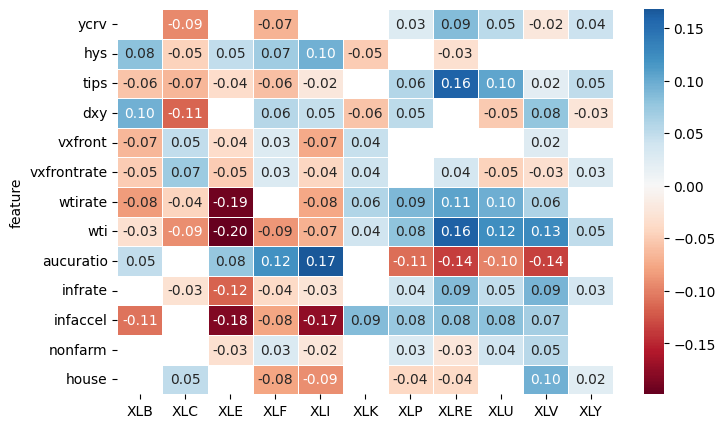

In [3]:
# macro correlation

import polars as pl
import itertools as it

macro_features = [
    "ycrv",
    "hys",
    "tips",
    "dxy",
    "vxfront",
    "vxfrontrate",
    "wtirate",
    "wti",
    "aucuratio",
    "infrate",
    "infaccel",
    "nonfarm",
    "house",
]

corr = (
    pl.read_parquet("macro-features.parquet")
    .join(
        pl.read_parquet("micro-features.parquet")
        .select(["date", "fwdalpha", "etf"])
        .pivot(index="date", columns="etf", values="fwdalpha"),
        on="date",
        how="inner",
    )
    .select(
        **{
            f"{p[0]}_{p[1]}": pl.corr(p[1], p[0], method="spearman")
            for p in it.product(macro_features, sector_etfs)
        }
    )
    .unpivot(variable_name="pair", value_name="ic")
    .with_columns(
        pl.col("pair").str.split_exact("_", 1).struct.rename_fields(["feature", "etf"])
    )
    .unnest("pair")
    .pivot(on="etf", index="feature", values="ic", aggregate_function=None)
)

import seaborn as sns
import matplotlib.pyplot as plt

# 1. Convert Polars to Pandas
# (Seaborn works best with Pandas or NumPy arrays)
pandas_matrix = corr.to_pandas().set_index("feature")

# 2. Plot the Heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(
    pandas_matrix,
    mask=pandas_matrix.abs() <= 0.02,
    annot=True,
    fmt=".2f",
    cmap="RdBu",
    linewidths=0.5,
    center=0,
)

plt.savefig("macro-correlations.png")
# # plt.show()

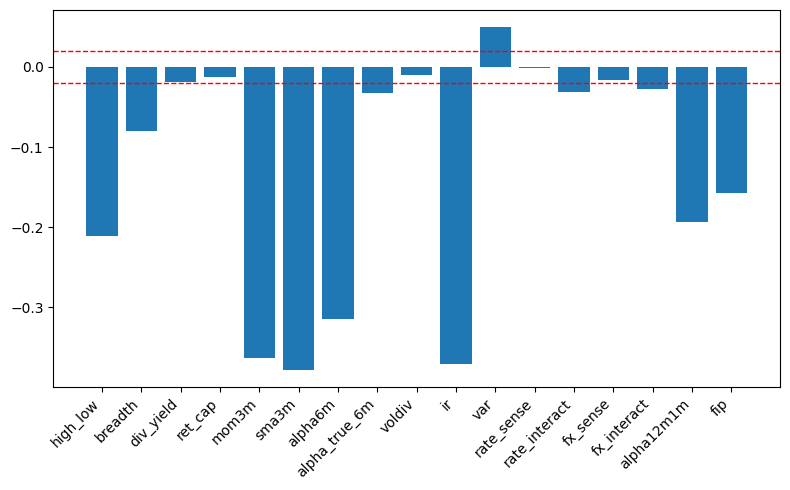

In [4]:
# micro cross-sectional correlation

import polars as pl
import itertools as it

micro_features = [
    "high_low",
    "breadth",
    "div_yield",
    "ret_cap",
    # *[f"mom{n}m" for n in [1, 3, 6, 12]],
    "mom3m",
    # *[f"sma{n}m" for n in [1, 3, 6, 12]],
    "sma3m",
    "alpha6m",
    "alpha_true_6m",
    "voldiv",
    "ir",
    # *[f"alpha{n}m" for n in [1, 3, 6, 12]],
    "var",
    "rate_sense",
    "rate_interact",
    "fx_sense",
    "fx_interact",
    "alpha12m1m",
    # sma12m1m
    # mom12m1m
    "fip",
]

corr = pl.read_parquet("micro-features.parquet").select(
    **{
        p: pl.corr(
            rank(pl.col("fwdalpha")).over("date"),
            rank(pl.col(p)).over("date"),
            method="pearson",
        )
        for p in micro_features
    }
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.bar(corr.columns, corr.row(0))
plt.xticks(rotation=45, ha="right")
plt.axhline(0.02, color="red", linestyle="--", linewidth=1)
plt.axhline(-0.02, color="red", linestyle="--", linewidth=1)

plt.tight_layout()

plt.savefig("micro-correlations.png")
# # plt.show()

/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_65946/3982835925.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  ics = train_df[test_mask].groupby('date').apply(compute_ic).dropna()
/var/folders/tl/9yq9dyyj1sl6tn4r875nj5ym0000gn/T/ipykernel_65946/3982835925.py:68: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  spreads = train_df[test_mask].groupby('date').apply(compute_spread).dropna()


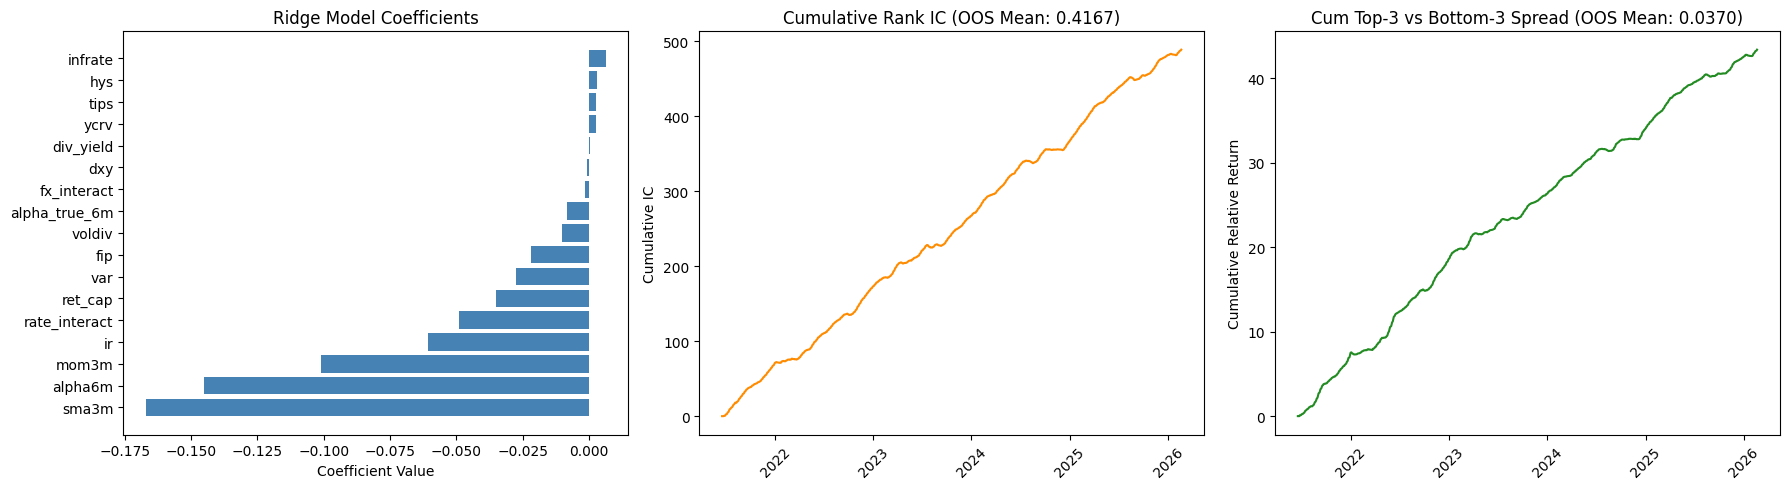

In [5]:
# Model Training and Evaluation

import polars as pl
import numpy as np
import pandas as pd
import pandas as pd
from sklearn.linear_model import Ridge
from scipy.stats import spearmanr
import matplotlib.pyplot as plt

# 1. Load Data
df = pl.read_parquet("micro-features.parquet").sort("date")
macro = pl.read_parquet("macro-features.parquet").sort("date")

# 2. Join Macro and Micro
df = df.join_asof(macro, on="date", strategy="backward")

# 3. Define Features
features = [
    "mom3m", "sma3m", "alpha6m", "alpha_true_6m", "voldiv", "ir", "var", 
    "rate_interact", "fx_interact", "fip", "div_yield", "ret_cap",
    "ycrv", "hys", "tips", "dxy", "infrate", "xsec_corr"
]

target = "fwdret"

# Filter out early nulls
train_df = df.select(["date", "etf", target] + features).drop_nulls().to_pandas()
train_df['date'] = pd.to_datetime(train_df['date'])

# Target Transformation: Predict the Cross-Sectional Rank of the Forward Alpha
train_df['target_rank'] = train_df.groupby('date')[target].rank(pct=True)



# 4. Train/Test Split (Time-based split at 2020)
split_date = pd.to_datetime("2020-01-01")
train_mask = train_df['date'] < split_date
test_mask = train_df['date'] >= split_date

X_train, y_train = train_df.loc[train_mask, features], train_df.loc[train_mask, target]
model = Ridge(alpha=100.0) 
model.fit(X_train, y_train)

# Predict on ALL data
train_df['prediction'] = model.predict(train_df[features])






# 7. Evaluate Cross-Sectional IC
def compute_ic(group):
    if len(group) == 11:
        corr, _ = spearmanr(group['prediction'], group[target])
        return corr
    return np.nan

# Calculate daily ICs
ics = train_df.groupby('date').apply(compute_ic).dropna()
cumulative_ic = ics.cumsum()

# Calculate daily Quantile Spread (Top 3 vs Bottom 3)
def compute_spread(group):
    if len(group) == 11:
        sorted_g = group.sort_values('prediction')
        bottom = sorted_g.iloc[:1][target].mean()
        top = sorted_g.iloc[-1:][target].mean()
        return top - bottom
    return np.nan

spreads = train_df.groupby('date').apply(compute_spread).dropna()
cumulative_spread = spreads.cumsum()

# 8. Plot Results
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Model Coefficients
coef_df = pd.DataFrame({"Feature": features, "Coefficient": model.coef_}).sort_values(by="Coefficient")
axes[0].barh(coef_df["Feature"], coef_df["Coefficient"], color='steelblue')
axes[0].set_title("Ridge Model Coefficients")
axes[0].set_xlabel("Coefficient Value")

# Plot 2: Cumulative Information Coefficient (IC)
axes[1].plot(cumulative_ic.index, cumulative_ic.values, color='darkorange')
axes[1].set_title(f"Cumulative IC (Predicting Fwd Return) (OOS Mean: {ics.mean():.4f})")
axes[1].set_ylabel("Cumulative IC")
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: Cumulative Quantile Spread
axes[2].plot(cumulative_spread.index, cumulative_spread.values, color='forestgreen')
axes[2].set_title(f"Cum Staggered L/S Spread (OOS Mean: {spreads.mean():.4f})")
axes[2].set_ylabel("Cumulative Relative Return")
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig("model-evaluation.png")
# # plt.show()

Building Portfolio and Evaluating Trades...

--- PORTFOLIO CONSTRUCTION & EVALUATION ---
Holding Period: 4-Week Staggered (Rebalance 25% every Tuesday)
Annualized Return: 7.76%
Annualized Volatility: 13.44%
Sharpe Ratio: 0.58
Max Drawdown: -20.20%
Annualized Information Ratio vs SPY: -0.31

--- PERIOD BREAKDOWN ---
Post-2020 (Historical Out-of-Sample): Ann Ret 7.76%, Vol 13.44%, Sharpe 0.58
Final Strategy Cumulative Return: 42.90%
Final SPY Cumulative Return: 65.69%


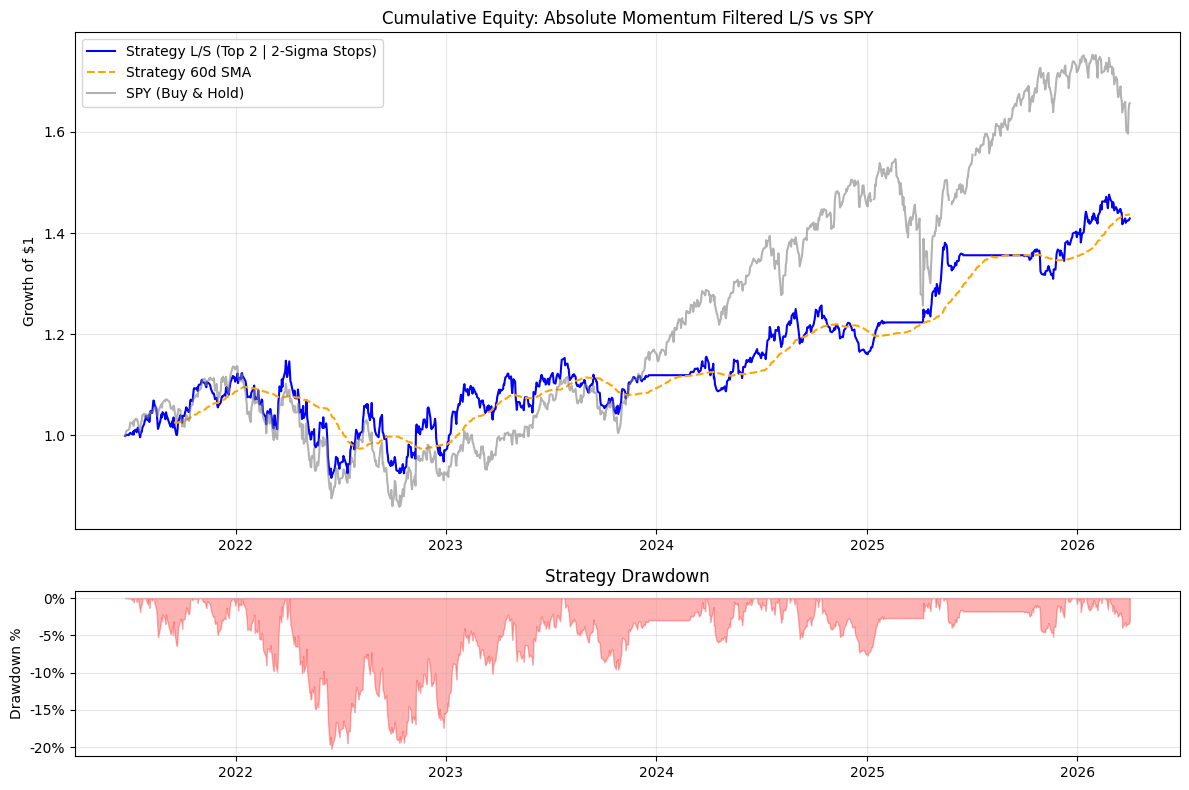

In [6]:
# Portfolio Construction and Trade-Level Evaluation

import polars as pl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("Building Portfolio and Evaluating Trades...")

# 1. Load Daily Prices & Calculate Returns
yf_df = pl.read_parquet("yf.parquet").to_pandas()
yf_df['date'] = pd.to_datetime(yf_df['ts']).dt.normalize()

# Pivot close prices to get a daily price matrix
closes = yf_df.pivot(index='date', columns='symbol', values='close').sort_index()
sector_etfs = ["XLB", "XLC", "XLE", "XLF", "XLI", "XLK", "XLP", "XLRE", "XLU", "XLV", "XLY"]

# Calculate daily simple returns
# Calculate daily simple returns
daily_rets = closes[sector_etfs].pct_change(fill_method=None)
spy_rets = closes['SPY'].pct_change(fill_method=None)

# Calculate 60-day rolling annualized volatility (EWMA or simple Std Dev)
# We'll use 60-day simple standard deviation for robust inverse-vol weighting
rolling_vol = daily_rets.rolling(window=60).std() * np.sqrt(252)


# 2. Get Model Predictions (from the test set)
# train_df and test_mask are defined in the previous cell
preds = train_df.pivot(index='date', columns='etf', values='prediction').sort_index()


# 3. Identify Rebalance Dates (Every Tuesday)
trading_dates = pd.Series(preds.index)
rebalance_dates = trading_dates[trading_dates.dt.dayofweek == 1].tolist() # Tuesday = 1

# 4. Calculate Target Weights (Staggered 1/4th overlapping sub-portfolios)
# We maintain 4 independent "tranches". Each tranche is rebalanced every 4 weeks.
# Tranche 0: Weeks 0, 4, 8...
# Tranche 1: Weeks 1, 5, 9...
# Tranche 2: Weeks 2, 6, 10...
# Tranche 3: Weeks 3, 7, 11...

# Instead of tracking tranches explicitly, we can just calculate the Target Weight for the *entire* 
# portfolio every Tuesday, and then apply a rolling 4-week average to the weights!
# Mathematically: If we invest 25% of our equity into the new signal every week, and hold for 4 weeks, 
# the total portfolio weight on any given day is exactly the average of the signals generated over the last 4 weeks.

# 4. Calculate Target Weights (Staggered 1/4th overlapping sub-portfolios)
# We explicitly track 4 independent tranches so we can apply precise stop-losses to each.
daily_weights = pd.DataFrame(0.0, index=closes.index, columns=sector_etfs)

tranche_w = {i: pd.Series(0.0, index=sector_etfs) for i in range(4)}
tranche_stops = {i: pd.Series(np.nan, index=sector_etfs) for i in range(4)}

# Stop Loss: 2-Sigma of trailing 1-Week Volatility
sigma_2w = daily_rets.rolling(window=60).std() * np.sqrt(5) * 2.0

lows = yf_df.pivot(index='date', columns='symbol', values='low').sort_index()[sector_etfs]
highs = yf_df.pivot(index='date', columns='symbol', values='high').sort_index()[sector_etfs]

rb_idx = 0
for day in closes.index:
    # 1. Rebalance if Tuesday
    if day in rebalance_dates:
        t_idx = rb_idx % 4
        rb_idx += 1
        
        tranche_w[t_idx].loc[:] = 0.0
        tranche_stops[t_idx].loc[:] = np.nan
        
        if day in preds.index and day in rolling_vol.index:
            day_preds = preds.loc[day].dropna()
            day_vols = rolling_vol.loc[day].dropna()
            day_sigmas = sigma_2w.loc[day].dropna()
            
            common_etfs = day_preds.index.intersection(day_vols.index)
            if len(common_etfs) == 11:
                sorted_preds = day_preds.loc[common_etfs].sort_values()
                
                # Absolute filters
                positive_preds = sorted_preds[sorted_preds > 0.0]
                negative_preds = sorted_preds[sorted_preds < 0.0]
                
                # Allocate to Longs (Max 2)
                if len(positive_preds) > 0:
                    longs = positive_preds.index[-min(2, len(positive_preds)):]
                    inv_vols = 1.0 / day_vols.loc[longs]
                    tranche_w[t_idx].loc[longs] = inv_vols / inv_vols.sum()
                    tranche_stops[t_idx].loc[longs] = closes.loc[day, longs] * (1.0 - day_sigmas.loc[longs])
                    
                # Allocate to Shorts (Max 2)
                if len(negative_preds) > 0:
                    shorts = negative_preds.index[:min(2, len(negative_preds))]
                    inv_vols = 1.0 / day_vols.loc[shorts]
                    tranche_w[t_idx].loc[shorts] = -inv_vols / inv_vols.sum()
                    tranche_stops[t_idx].loc[shorts] = closes.loc[day, shorts] * (1.0 + day_sigmas.loc[shorts])
                    
    # 2. Check Stops (Did the intra-week Low break our stop loss?)
    if day in lows.index and day in highs.index:
        for t in range(4):
            # Long Stops
            long_mask = tranche_w[t] > 0
            if long_mask.any():
                hit_long = lows.loc[day] < tranche_stops[t]
                tranche_w[t] = tranche_w[t].where(~(long_mask & hit_long), 0.0)
            
            # Short Stops
            short_mask = tranche_w[t] < 0
            if short_mask.any():
                hit_short = highs.loc[day] > tranche_stops[t]
                tranche_w[t] = tranche_w[t].where(~(short_mask & hit_short), 0.0)

    # 3. Calculate Total Portfolio Weight (Average of the 4 active tranches)
    daily_weights.loc[day] = sum(tranche_w[t] for t in range(4)) / 4.0

# 5. Shift by 1 because weights formed at close of day T earn returns on day T+1
active_weights = daily_weights.shift(1).fillna(0.0)




# Ensure date indices align
common_dates = active_weights.index.intersection(daily_rets.index)
active_weights = active_weights.loc[common_dates]
daily_rets_aligned = daily_rets.loc[common_dates]
spy_rets_aligned = spy_rets.loc[common_dates]


# Calculate Portfolio Daily Return (Dot product of weights and returns)
port_daily_rets = (active_weights * daily_rets_aligned).sum(axis=1)

# Filter out periods where the model had no predictions (e.g., waiting for 3y lookbacks on new ETFs)
gross_exposure = active_weights.abs().sum(axis=1)
active_period = gross_exposure[gross_exposure > 0.1].index
if not active_period.empty:
    start_eval = active_period[0]
    port_daily_rets = port_daily_rets.loc[start_eval:]
    spy_rets_aligned = spy_rets_aligned.loc[start_eval:]
    active_weights = active_weights.loc[start_eval:]

# Cumulative Equity
cum_port = (1 + port_daily_rets).cumprod()
cum_spy = (1 + spy_rets_aligned).cumprod()

# 60d SMA of Cumulative Equity
sma_60d = cum_port.rolling(60).mean()

# Drawdown
rolling_max = cum_port.cummax()
drawdown = cum_port / rolling_max - 1.0
max_drawdown = drawdown.min()

# 6. Trade-Level Evaluation
# A "trade" is the performance of the entire portfolio between weekly rebalance dates
trade_returns = []
for i in range(len(rebalance_dates)-1):
    start_dt = rebalance_dates[i]
    end_dt = rebalance_dates[i+1]
    
    if start_dt in port_daily_rets.index and end_dt in port_daily_rets.index:
        period_rets = port_daily_rets.loc[start_dt:end_dt].iloc[1:]
        if len(period_rets) > 0:
            tr_ret = (1 + period_rets).prod() - 1
            trade_returns.append(tr_ret)
trade_returns = pd.Series(trade_returns)
mean_trade_ret = trade_returns.mean()
std_trade_ret = trade_returns.std()

# Information Ratio vs SPY (Annualized)
active_returns = port_daily_rets - spy_rets_aligned
ir = (active_returns.mean() / active_returns.std()) * np.sqrt(252)



years = len(port_daily_rets) / 252.0
ann_ret = (cum_port.iloc[-1] ** (1/years)) - 1
ann_vol = port_daily_rets.std() * np.sqrt(252)
sharpe = ann_ret / ann_vol


print("\n--- PORTFOLIO CONSTRUCTION & EVALUATION ---")
print(f"Holding Period: 4-Week Staggered (Rebalance 25% every Tuesday)")
print(f"Annualized Return: {ann_ret*100:.2f}%")
print(f"Annualized Volatility: {ann_vol*100:.2f}%")
print(f"Sharpe Ratio: {sharpe:.2f}")
print(f"Max Drawdown: {max_drawdown*100:.2f}%")
print(f"Annualized Information Ratio vs SPY: {ir:.2f}")



print("\n--- PERIOD BREAKDOWN ---")
pre_2020 = port_daily_rets.loc[:"2019-12-31"]
post_2020 = port_daily_rets.loc["2020-01-01":]

if not pre_2020.empty:
    pre_ann = ((1 + pre_2020).prod() ** (252 / len(pre_2020))) - 1
    pre_vol = pre_2020.std() * np.sqrt(252)
    print(f"Pre-2020 (Historical 'In-Sample'): Ann Ret {pre_ann*100:.2f}%, Vol {pre_vol*100:.2f}%, Sharpe {pre_ann/pre_vol:.2f}")

if not post_2020.empty:
    post_ann = ((1 + post_2020).prod() ** (252 / len(post_2020))) - 1
    post_vol = post_2020.std() * np.sqrt(252)
    print(f"Post-2020 (Historical Out-of-Sample): Ann Ret {post_ann*100:.2f}%, Vol {post_vol*100:.2f}%, Sharpe {post_ann/post_vol:.2f}")

# 7. Plotting

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), gridspec_kw={'height_ratios': [3, 1]})

# Equity Curve
ax1.plot(cum_port.index, cum_port, label='Strategy L/S (Top 2 | 2-Sigma Stops)', color='blue', linewidth=1.5)
ax1.plot(sma_60d.index, sma_60d, label='Strategy 60d SMA', color='orange', linestyle='--', linewidth=1.5)
ax1.plot(cum_spy.index, cum_spy, label='SPY (Buy & Hold)', color='gray', alpha=0.6, linewidth=1.5)
ax1.set_title("Cumulative Equity: Absolute Momentum Filtered L/S vs SPY")
ax1.set_ylabel("Growth of $1")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Drawdown Curve
ax2.fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.3)
ax2.set_title("Strategy Drawdown")
ax2.set_ylabel("Drawdown %")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:.0f}%".format(x*100)))
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("portfolio-construction.png")
# # plt.show()


print(f'Final Strategy Cumulative Return: {(cum_port.iloc[-1] - 1.0) * 100:.2f}%')
print(f'Final SPY Cumulative Return: {(cum_spy.iloc[-1] - 1.0) * 100:.2f}%')